# PLS Regression — implementação causal

**Etapa:** auditoria da padronização e dos componentes

Verificamos como o scaler e o PLS são ajustados dentro de cada janela walk-forward, sem usar validação ou teste no ajuste.

**Entrada:** base modelável, 12 features e parâmetro n_components=11  
**Resultado principal:** padronização por janela e número de componentes validados


## 1. Importações, caminhos e funções

In [1]:
from pathlib import Path
import hashlib, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from IPython.display import display

warnings.filterwarnings("ignore")
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "bases/grupo5/gold_daily_modeling.csv").exists())
BASE_PATH = ROOT / "bases/grupo5/gold_daily_modeling.csv"
OUT = ROOT / "analyses/grupo5/outputs"
OUT.mkdir(parents=True, exist_ok=True)
PROTOCOL_PATH = OUT / "protocol.json"
SEED = 42
np.random.seed(SEED)

def sha256(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

def load_data():
    df = pd.read_csv(BASE_PATH, parse_dates=["DATE"]).sort_values("DATE").reset_index(drop=True)
    raw_path = ROOT / "bases/grupo5-tratamento/gold_daily_prices.csv"
    raw = pd.read_csv(raw_path, sep=None, engine="python", parse_dates=["DATE"])
    raw["EXPECTED_TARGET"] = pd.to_numeric(raw["VALUE"], errors="coerce").shift(-1)
    raw["TARGET_DATE"] = raw["DATE"].shift(-1)
    target_lookup = raw[["DATE", "TARGET_DATE", "EXPECTED_TARGET"]]
    df = df.merge(target_lookup, on="DATE", how="left", validate="one_to_one")
    assert df["DATE"].is_monotonic_increasing and not df["DATE"].duplicated().any()
    assert "TARGET_UP" not in df.columns and not df.isna().any().any()
    assert np.allclose(df["TARGET"], df["EXPECTED_TARGET"])
    return df.drop(columns="EXPECTED_TARGET")



In [2]:
def load_protocol(require_data_decisions=False):
    if not PROTOCOL_PATH.exists():
        raise RuntimeError("DECISÃO NECESSÁRIA: execute 01_documentacao_bases.ipynb primeiro.")
    protocol = json.loads(PROTOCOL_PATH.read_text(encoding="utf-8"))
    if protocol.get("protocol_version") != 2:
        raise RuntimeError("Protocolo desatualizado: execute novamente 01_documentacao_bases.ipynb.")
    if protocol["dataset_sha256"] != sha256(BASE_PATH):
        raise RuntimeError("A base congelada não corresponde ao hash do protocolo.")
    if require_data_decisions:
        missing = [k for k in ("source", "unit", "cleaning", "features", "seasonal_period") if not protocol["decisions"].get(k)]
        if missing:
            raise RuntimeError(f"DECISÃO NECESSÁRIA: complete as decisões {missing} antes de modelar.")
    return protocol

def save_protocol(protocol):
    PROTOCOL_PATH.write_text(json.dumps(protocol, indent=2, ensure_ascii=False), encoding="utf-8")

def origins(protocol, split):
    return protocol["origins"][split]

def target_dates(df, origin_ids):
    return df["TARGET_DATE"].iloc[origin_ids].to_numpy()


## 2. Scaler, componentes e previsão causal

In [3]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler

df = load_data()
protocol = load_protocol(require_data_decisions=True)
features = protocol["decisions"]["features"]
params = protocol["decisions"]["accepted_parameters"]["PLS_Regression"]
validation_origins = origins(protocol, "validation")
selected_origins = [
    validation_origins[0],
    validation_origins[len(validation_origins) // 2],
    validation_origins[-1],
]

rows = []
for origin in selected_origins:
    train = df.iloc[:origin]
    scaler = StandardScaler().fit(train[features])
    transformed = scaler.transform(train[features])
    rows.append(
        {
            "origin_index": origin,
            "date_origin": df.loc[origin, "DATE"],
            "training_rows": len(train),
            "scaler_fit_end_date": df.loc[origin - 1, "DATE"],
            "maximum_abs_scaled_mean": np.abs(transformed.mean(axis=0)).max(),
            "n_features": len(features),
            "n_components": params["n_components"],
        }
    )

scaler_audit = pd.DataFrame(rows)
assert (scaler_audit["maximum_abs_scaled_mean"] < 1e-10).all()
assert "TARGET" not in features and "TARGET_UP" not in features
scaler_audit.to_csv(OUT / "pls_scaler_audit.csv", index=False)
display(scaler_audit)

tuning = pd.read_csv(OUT / "tuning_candidates_PLS_Regression.csv")
tuning["n_components"] = tuning["parameters"].apply(
    lambda value: json.loads(value)["n_components"]
)
tuning = tuning.sort_values("n_components")


,origin_index,date_origin,training_rows,scaler_fit_end_date,maximum_abs_scaled_mean,n_features,n_components
0,6904,2000-06-27,6904,2000-06-23,8.068736e-16,12,11
1,7644,2003-11-27,7644,2003-11-26,1.784723e-16,12,11
2,8379,2007-05-21,8379,2007-05-18,5.698588e-16,12,11


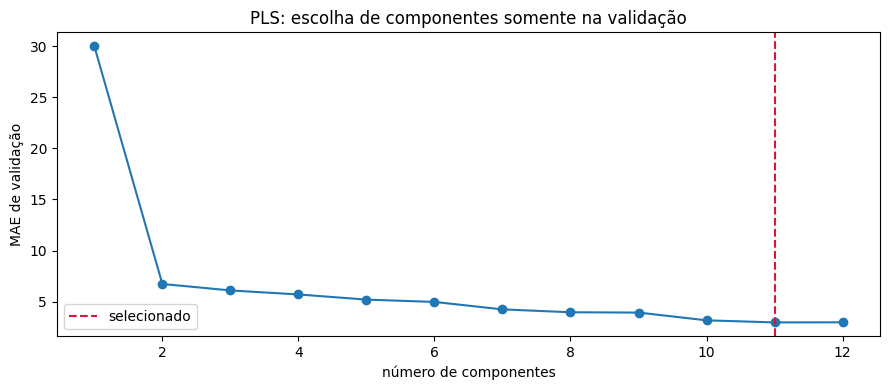

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(tuning["n_components"], tuning["validation_mae"], marker="o")
ax.axvline(params["n_components"], color="crimson", linestyle="--", label="selecionado")
ax.set_xlabel("número de componentes")
ax.set_ylabel("MAE de validação")
ax.set_title("PLS: escolha de componentes somente na validação")
ax.legend()
plt.tight_layout()
plt.savefig(OUT / "pls_validation_components.png", dpi=150, bbox_inches="tight")
plt.show()


## Interpretação

O StandardScaler é reajustado em cada janela usando somente treino. Onze componentes foram definidos na validação e permaneceram congelados no teste.

## Artefatos

Arquivos usados ou produzidos nesta etapa:

- `outputs/pls_scaler_audit.csv`
- `outputs/pls_validation_components.png`
- `outputs/hyperparameters.csv`